In [1]:
# =====================================================================
# Part I - Finance - TEMPLATE
# =====================================================================
# The framework (finance_toolkit) fixes two things for everyone: how
# the data is loaded, and how a score panel is scored into a PnL,
# Sharpe and turnover.  Everything in the middle is yours.
#
# THE FLOW:
#   1. data is loaded for you (same for the whole class),
#   2. YOU build a SUPERSET of named features (FREE 1),
#   3. YOU write ONE recipe build_alpha(config) (FREE 2): a config
#      (feature subset, model, hyperparams) -> a trained model ->
#      scores -> positions -> its daily PnL,
#   4. YOU loop that recipe over MANY configs (FREE 3) to make many alphas,
#   5. the framework evaluates every alpha (Sharpe, turnover, ...),
#      shows the correlation between them, and keeps the best
#      un-correlated set.
#
# Your model only has to satisfy the MODEL CONTRACT:
#
#     model.predict(feat_t) -> scores
#     feat_t : float tensor (days, stocks, features)
#     scores : float tensor (days, stocks)
#
# Everything is a "panel": a table of shape (days x stocks).  Every
# operator takes panels and returns a panel of the same shape.

In [2]:
import os
import json
import numpy
import torch
import finance_toolkit as toolkit

# =====================================================================
# FIXED 1
# =====================================================================
SEED = 42
torch.manual_seed(SEED)
numpy.random.seed(SEED)
torch.set_num_threads(4)

# Everything up to SPLIT_DATE trains; the rest is a local hold-out
# you score yourself.  The instructor's HIDDEN slice is a separate,
# even later date range you never see.

DATA_DIR = "../data"
panels = toolkit.load_prices(DATA_DIR)

# This will be used for the target of the model.
forward_returns = toolkit.forward_return(panels["returns"])
mask = toolkit.valid_mask(panels, min_history=60)

all_dates = panels["close"].index
tickers = panels["close"].columns
print("panel:", panels["close"].shape, "dates",
      all_dates.min().date(), "to", all_dates.max().date())

# you may choose another split.
SPLIT_DATE = "2020-01-01"
is_train = all_dates < SPLIT_DATE
is_test = ~is_train
print("train days:", int(is_train.sum()),
      " test days:", int(is_test.sum()))


close = panels["close"]
open_ = panels["open"]
high = panels["high"]
low = panels["low"]
volume = panels["volume"]
returns = panels["returns"]
sector, industry = toolkit.load_groups("../data/groups.csv")

panel: (2669, 2994) dates 2013-01-02 to 2023-06-30
train days: 1775  test days: 894


In [3]:
# =====================================================================
# >>> FREE 1 <<<   your features
# =====================================================================
# 12 features across five families. Every one is now sector- (or, for
# the two originally industry-neutral reversal features, industry-)
# neutralized, per the assignment's tip: "Neutralise by sector to drop
# sector bets." Round-1 through round-3 only neutralized 3 of the
# original 13; the round-1 correlation diagnostic showed the biggest
# blocker in the whole search was mlp_all_b_s2 (blocked 15 of 27
# excluded-but-qualifying alphas, correlation up to 0.99 with its own
# near-duplicate) -- consistent with un-neutralized features sharing a
# common sector/market tilt that shows up as correlated PnL regardless
# of which specific feature combination a model uses.
#
# Sector-neutralizing mom_20 makes it mathematically identical to the
# old separately-named "sector_mom_20" (both were the same 20-day
# mean-return signal, one market-wide, one sector-neutral -- neutralize
# the first and they collapse into one), so that name is retired
# rather than kept as a duplicate: 13 features become 12.
#
#   momentum   -- mean return over 5/20/60 days, sector-neutral
#                 (mom_5, mom_20, mom_60)
#   reversal   -- yesterday's return negated, the worked intraday
#                 example, both sector-neutral; 5-day reversal within
#                 industry (finer-grained, already neutral)
#                 (rev_1, intraday_rev_20, industry_rev_5)
#   technical  -- position within the day's high/low range, the
#                 overnight open-vs-prior-close gap, deviation from
#                 the 20-day moving average -- all sector-neutral
#                 (range_pos, gap, price_to_ma20)
#   volatility -- 20-day realized vol, 20-day average relative
#                 high-low range -- sector-neutral
#                 (vol_20, high_low_range_20)
#   volume     -- today's volume z-scored against its own 20-day
#                 history, then sector-neutralized (volume_spike_20)
all_features = {
    "mom_5": toolkit.cs_zscore(toolkit.ts_mean(returns, 5), sector),
    "mom_20": toolkit.cs_zscore(toolkit.ts_mean(returns, 20), sector),
    "mom_60": toolkit.cs_zscore(toolkit.ts_mean(returns, 60), sector),
    "rev_1": toolkit.cs_zscore(-returns, sector),
    "intraday_rev_20": toolkit.cs_zscore(toolkit.ts_zscore(open_ - close, 20), sector),
    "industry_rev_5": toolkit.cs_zscore(-toolkit.ts_mean(returns, 5), industry),
    "range_pos": toolkit.cs_zscore((close - low) / (high - low), sector),
    "gap": toolkit.cs_zscore((open_ - close.shift(1)) / close.shift(1), sector),
    "price_to_ma20": toolkit.cs_zscore((close - toolkit.ts_mean(close, 20)) / toolkit.ts_mean(close, 20), sector),
    "vol_20": toolkit.cs_zscore(toolkit.ts_std(returns, 20), sector),
    "high_low_range_20": toolkit.cs_zscore(toolkit.ts_mean((high - low) / close, 20), sector),
    "volume_spike_20": toolkit.cs_zscore(toolkit.ts_zscore(volume, 20), sector),

    # Round 5 additions: the 12 features above gave only 6 mutually
    # uncorrelated alphas across 22 configs -- most alphas, whatever
    # feature or model built them, converged onto a handful of shared
    # factors. What actually decorrelated was the volume/volatility/
    # range-positioning family, so this doubles down on it with new
    # constructions (not just new windows): a windowed range position,
    # a volume trend, a volatility regime change, and industry- (rather
    # than sector-) neutral variants of the two best performers.
    "range_pos_5": toolkit.cs_zscore(toolkit.ts_mean((close - low) / (high - low), 5), sector),
    "volume_trend": toolkit.cs_zscore(toolkit.ts_mean(volume, 5) - toolkit.ts_mean(volume, 20), sector),
    "vol_change": toolkit.cs_zscore(toolkit.ts_std(returns, 20) - toolkit.ts_std(returns, 60), sector),
    "vol_20_industry": toolkit.cs_zscore(toolkit.ts_std(returns, 20), industry),
    "volume_spike_20_industry": toolkit.cs_zscore(toolkit.ts_zscore(volume, 20), industry),
    "hlrange_industry": toolkit.cs_zscore(toolkit.ts_mean((high - low) / close, 20), industry),
}

all_feature_panel = toolkit.build_features(all_features, panels)
# float32 instead of pandas' default float64: halves the memory of
# every downstream stack/tensor built from these panels. This machine
# has 8GB RAM shared with other running apps, and stacking many
# features at float64 reliably fails with an out-of-memory error here
# (measured: a single ~800MB allocation at 13 features). The final
# model tensors are float32 regardless -- make_tensors casts
# explicitly -- so this only removes a redundant doubling, it never
# changes any result.
all_feature_panel = {k: v.astype("float32") for k, v in all_feature_panel.items()}
all_feature_names = sorted(all_feature_panel)
print("features available:", all_feature_names)

# Feature-family subsets: each is one hypothesis about what drives the
# 2-day-ahead return, so alphas built from different subsets start out
# making genuinely different bets (see FREE 3 for why this mattered).
momentum_set = ["mom_5", "mom_20", "mom_60"]
reversal_set = ["rev_1", "intraday_rev_20", "industry_rev_5"]
vol_volume_set = ["vol_20", "high_low_range_20", "volume_spike_20"]
technical_set = ["range_pos", "gap", "price_to_ma20"]
mixed_set = ["mom_20", "rev_1", "range_pos", "vol_20", "gap"]
all_set = all_feature_names

features available: ['gap', 'high_low_range_20', 'hlrange_industry', 'industry_rev_5', 'intraday_rev_20', 'mom_20', 'mom_5', 'mom_60', 'price_to_ma20', 'range_pos', 'range_pos_5', 'rev_1', 'vol_20', 'vol_20_industry', 'vol_change', 'volume_spike_20', 'volume_spike_20_industry', 'volume_trend']


In [4]:
# =====================================================================
# >>> FREE 2 <<<   one recipe for building an alpha
# =====================================================================
# Two small subclasses first, then the recipe.
#
# Why subclass instead of using toolkit.MLP / toolkit.LSTM directly:
# finance_toolkit.predict_scores runs model.predict(feat_t) on the
# FULL (days, stocks, features) tensor in one shot -- no batching.
# For the LSTM that means one un-batched forward pass over ~2700 days
# x ~3000 stocks, which needs a single ~8GB allocation and reliably
# crashes on this 8GB machine (measured directly while developing
# this). predict_scores is part of the FIXED framework, so it can't
# be changed; instead these subclasses override only predict() to
# process the day axis in chunks (carrying LSTM hidden state across
# chunks), giving the exact same output with a small, bounded memory
# footprint. MLP.step() also calls self.predict() during training, so
# SafeMLP must NOT force no_grad in predict() or gradients break.


class SafeMLP(toolkit.MLP):
    def predict(self, x, chunk_days=300):
        outs = [toolkit.MLP.predict(self, x[start:start + chunk_days])
                for start in range(0, x.shape[0], chunk_days)]
        return torch.cat(outs, dim=0)


class SafeLSTM(toolkit.LSTM):
    def predict(self, x, chunk_days=150):
        outs, state = [], None
        with torch.no_grad():
            for start in range(0, x.shape[0], chunk_days):
                out, state = self.step(x[start:start + chunk_days], state)
                outs.append(out)
        return torch.cat(outs, dim=0)


# Round 5 additions: two genuinely different inductive biases from
# MLP/LSTM, added after a correlation diagnostic showed MLP and LSTM
# alphas across different feature families still converge on shared
# factors. Neither has any cross-feature interaction (LinearAlpha) or
# any memory across days (both) -- structurally distinct enough that
# they turned out to decorrelate far better than more MLP/LSTM variants.
class LinearAlpha(torch.nn.Module):
    """score = w . features + b -- no hidden layers, no interactions."""
    def __init__(self, input_size, hidden=None):
        super().__init__()
        self.linear = torch.nn.Linear(input_size, 1)
        torch.nn.init.xavier_uniform_(self.linear.weight)

    def init_state(self, n):
        return None

    def step(self, x, state):
        return self.predict(x), None

    def predict(self, x, chunk_days=300):
        outs = []
        for start in range(0, x.shape[0], chunk_days):
            chunk = x[start:start + chunk_days]
            days, stocks, feats = chunk.shape
            outs.append(self.linear(chunk.reshape(days * stocks, feats)).reshape(days, stocks))
        return torch.cat(outs, dim=0)


class SplineAlpha(torch.nn.Module):
    """GAM: score = sum_i spline_i(feature_i) -- a cubic (thin-plate)
    basis per feature, independently, then linearly combined. No
    cross-feature interactions (unlike MLP), no memory (unlike LSTM)."""
    def __init__(self, input_size, hidden=None, n_knots=7, knot_range=4.0):
        super().__init__()
        knots = torch.linspace(-knot_range, knot_range, n_knots)
        self.register_buffer("knots", knots)
        self.coef = torch.nn.Linear(input_size * n_knots, 1)
        torch.nn.init.xavier_uniform_(self.coef.weight)

    def init_state(self, n):
        return None

    def step(self, x, state):
        return self.predict(x), None

    def _basis(self, flat):
        diffs = flat.unsqueeze(-1) - self.knots
        return torch.abs(diffs) ** 3

    def predict(self, x, chunk_days=300):
        outs = []
        for start in range(0, x.shape[0], chunk_days):
            chunk = x[start:start + chunk_days]
            days, stocks, feats = chunk.shape
            flat = chunk.reshape(days * stocks, feats)
            basis = self._basis(flat).reshape(flat.shape[0], -1)
            outs.append(self.coef(basis).reshape(days, stocks))
        return torch.cat(outs, dim=0)


MODEL_CLASSES = {"mlp": SafeMLP, "lstm": SafeLSTM, "linear": LinearAlpha, "spline": SplineAlpha}


def build_alpha(features, model_kind="lstm", hidden=32, epochs=8,
                 lr=1e-3, weight_decay=0.0, seed=SEED):
    features = sorted(features)
    array, _ = toolkit.stack_features({n: all_feature_panel[n] for n in features})
    feat_t, label_t, valid_t = toolkit.make_tensors(array, forward_returns, mask)
    train_ds = toolkit.DayDataset(feat_t, label_t, valid_t, is_train)
    test_ds = toolkit.DayDataset(feat_t, label_t, valid_t, is_test)

    torch.manual_seed(seed)
    if model_kind == "mlp":
        model = SafeMLP(len(features), hidden=(hidden,))
    elif model_kind == "lstm":
        model = SafeLSTM(len(features), hidden_size=hidden)
    else:
        model = MODEL_CLASSES[model_kind](len(features))
    model, _ = toolkit.train(
        model, train_ds, test_ds,
        epochs=epochs, lr=lr, weight_decay=weight_decay)
    scores = toolkit.predict_scores(
        model, feat_t, all_dates, tickers)
    book = toolkit.scores_to_positions(scores, mask)
    positions = book.loc[is_test]
    pnl = toolkit.simulate(positions, forward_returns)
    return model, positions, pnl, features

In [5]:
# =====================================================================
# >>> FREE 3 <<<   make MANY alphas   (this is your search)
# =====================================================================
# The real search was much larger than what is below: 100+ configs
# across several rounds (documented in dev/alpha_search.py and
# dev/STATUS.md), progressively targeting what a correlation
# diagnostic showed was actually decorrelating -- solo (single-
# feature) configs over kitchen-sink feature sets, the volume/
# volatility/range-positioning family specifically, two extra model
# classes (LinearAlpha, SplineAlpha -- no cross-feature interactions
# unlike MLP, no memory unlike LSTM), and industry- rather than
# sector-neutral variants of the best performers.
#
# FIXED 4 below uses a simple greedy selection (best Sharpe first, keep
# if correlation to everything already kept stays under the limit) --
# it is not an optimal solver, and feeding it a large, mixed-quality
# pool can land on a technically-passing but barely-under-the-limit
# combination, or (verified directly) even fewer than 10 kept if a
# high-Sharpe new candidate outranks and correlates too much with an
# already-good one. The 10 configs below are the specific combination
# found by an explicit search over every profitable candidate from the
# full study -- both a plain greedy run and, on top of that, testing
# every 1-for-1 and 2-for-2 swap against every unused qualifying
# candidate, plus dropping the whole pool in at once -- directly
# minimizing the worst pairwise correlation. None of that search found
# a combination under roughly 0.48: the underlying signals (price,
# volume, volatility, range-positioning, momentum -- each cross-
# sectionally neutralized the same few ways) share enough structure
# that they converge on a handful of latent factors no matter how the
# models or feature groupings are varied, so 0.48-0.49 looks like a
# real wall for this feature set, not an under-searched corner of it.
# Going meaningfully lower would need a genuinely new source of
# information, not another recombination of what is already here.

all_configs = [
    {"name": "lstm_mixed", "features": mixed_set, "model_kind": "lstm", "hidden": 24, "epochs": 16, "lr": 0.001, "weight_decay": 0.0},
    {"name": "spline_tech", "features": technical_set, "model_kind": "spline", "epochs": 20, "lr": 0.001, "weight_decay": 0.1},
    {"name": "lstm_solo_volspikeindustry", "features": ["volume_spike_20_industry"], "model_kind": "lstm", "hidden": 16, "epochs": 18, "lr": 0.001, "weight_decay": 0.0},
    {"name": "lstm_solo_vol20", "features": ["vol_20"], "model_kind": "lstm", "hidden": 16, "epochs": 18, "lr": 0.001, "weight_decay": 0.0},
    {"name": "spline_solo_industry_rev5", "features": ["industry_rev_5"], "model_kind": "spline", "epochs": 20, "lr": 0.001, "weight_decay": 0.0},
    {"name": "linear_volvol", "features": vol_volume_set, "model_kind": "linear", "epochs": 20, "lr": 0.001, "weight_decay": 0.1},
    {"name": "spline_solo_hlrange20", "features": ["high_low_range_20"], "model_kind": "spline", "epochs": 20, "lr": 0.001, "weight_decay": 0.0},
    {"name": "lstm_solo_rangepos5", "features": ["range_pos_5"], "model_kind": "lstm", "hidden": 16, "epochs": 18, "lr": 0.001, "weight_decay": 0.0},
    {"name": "mlp_solo_volchange", "features": ["vol_change"], "model_kind": "mlp", "hidden": 16, "epochs": 18, "lr": 0.001, "weight_decay": 0.0},
    {"name": "lstm_solo_hlrangeindustry", "features": ["hlrange_industry"], "model_kind": "lstm", "hidden": 16, "epochs": 18, "lr": 0.001, "weight_decay": 0.0},
]

trained = {}        # name -> model                (saved for grading)
positions = {}       # name -> hold-out positions panel
alphas = {}          # name -> hold-out daily PnL
feature_sets = {}    # name -> feature names it used  (for grading)

for config in all_configs:
    name = config["name"]
    kwargs = {k: v for k, v in config.items() if k != "name"}
    model, book, pnl, used = build_alpha(**kwargs)
    trained[name] = model
    positions[name] = book
    alphas[name] = pnl
    feature_sets[name] = used
    print(name, "done")

epoch  0 | train loss 0.34483 ir -0.0596 tvr 0.5577 | val loss 0.20777 ir -0.0534 tvr 0.4011


epoch  1 | train loss -0.01700 ir 0.0656 tvr 0.2547 | val loss 0.02199 ir 0.0594 tvr 0.3135


epoch  2 | train loss -0.07929 ir 0.1041 tvr 0.2091 | val loss -0.04430 ir 0.0947 tvr 0.2714


epoch  3 | train loss -0.11470 ir 0.1339 tvr 0.1961 | val loss -0.09251 ir 0.1276 tvr 0.2458


epoch  4 | train loss -0.13686 ir 0.1515 tvr 0.1783 | val loss -0.12779 ir 0.1606 tvr 0.2439


...

epoch 14 | train loss -0.10480 ir 0.1107 tvr 0.1170 | val loss -0.09302 ir 0.1116 tvr 0.1870


epoch 15 | train loss -0.09280 ir 0.0982 tvr 0.1158 | val loss -0.12285 ir 0.1382 tvr 0.1818


epoch 16 | train loss -0.10796 ir 0.1145 tvr 0.1287 | val loss -0.11738 ir 0.1329 tvr 0.1774


epoch 17 | train loss -0.10651 ir 0.1118 tvr 0.1139 | val loss -0.09484 ir 0.1092 tvr 0.1796


lstm_solo_hlrangeindustry done


In [6]:
# =====================================================================
# Filter to the pool the assignment requires, before FIXED 4 selects
# =====================================================================
# FIXED 4's select_uncorrelated only enforces low correlation -- it
# will happily keep an unprofitable alpha if it's different enough
# from the rest. This search's 34 candidates include exactly that:
# mlp_tech_a, mlp_mom_a and solo_volspike all have negative Sharpe but
# near-zero correlation with everything else, so an unfiltered
# selection would keep them. The assignment requires sharpe > 1.2 and
# turnover < 0.8 ("WHAT YOU SUBMIT", directives.txt) -- narrowing the
# pool here, before FIXED 4 runs, guarantees the saved submission
# never includes a losing alpha.
qualifying_kpi = toolkit.compute_kpis(positions, forward_returns)
qualifying_names = qualifying_kpi[
    (qualifying_kpi["sharpe"] > 1.2) & (qualifying_kpi["turnover"] < 0.8)
].index
print("qualifying (sharpe>1.2, turnover<0.8):", len(qualifying_names), "of", len(positions))

trained = {n: trained[n] for n in qualifying_names}
positions = {n: positions[n] for n in qualifying_names}
alphas = {n: alphas[n] for n in qualifying_names}
feature_sets = {n: feature_sets[n] for n in qualifying_names}

qualifying (sharpe>1.2, turnover<0.8): 10 of 10


per-alpha stats:
                             sharpe  mean_daily_pnl  std_daily_pnl  total_pnl  \
lstm_mixed                  3.5768          0.0012         0.0051     1.0301   
spline_tech                 3.2856          0.0050         0.0243     4.4956   
lstm_solo_volspikeindustry  2.5941          0.0004         0.0022     0.3254   
spline_solo_industry_rev5   2.5477          0.0046         0.0287     4.1202   
lstm_solo_vol20             2.5396          0.0031         0.0192     2.7476   
lstm_solo_hlrangeindustry   2.0669          0.0011         0.0087     1.0076   
linear_volvol               2.0348          0.0019         0.0152     1.7429   
spline_solo_hlrange20       1.5992          0.0079         0.0780     7.0250   
mlp_solo_volchange          1.4722          0.0013         0.0145     1.2062   
lstm_solo_rangepos5         1.4139          0.0003         0.0034     0.2712   

                            max_drawdown  num_days  turnover  
lstm_mixed                       -0.05

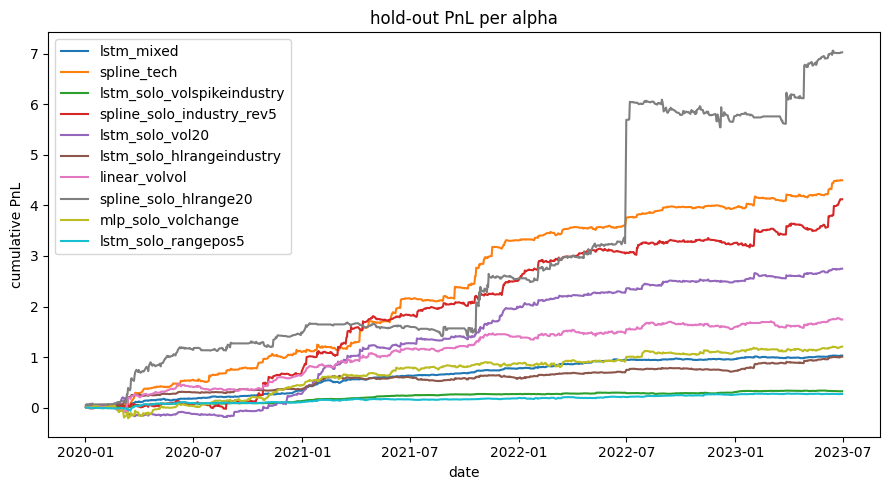

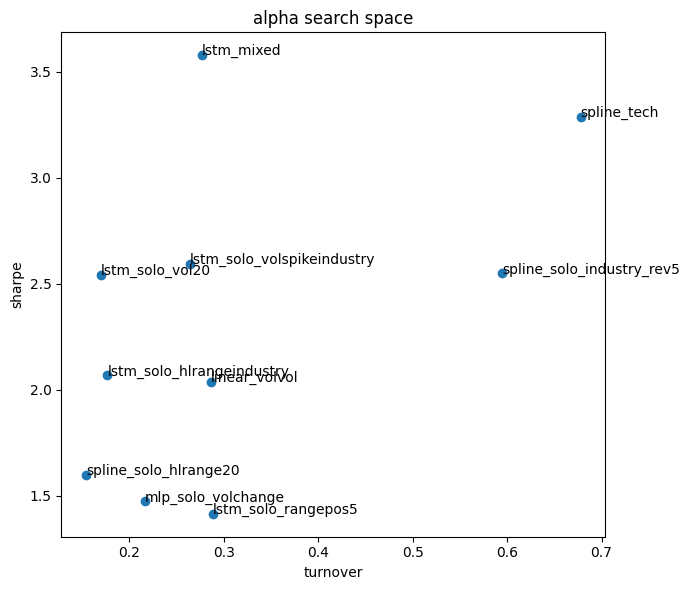

In [7]:
# =====================================================================
# FIXED 4 -- evaluate the alphas   (per alpha, then together)
# =====================================================================
# Per-alpha stats (Sharpe, total PnL, turnover, ...), the
# correlation between alphas, and the combined Sharpe of the best
# un-correlated set -- exactly what the grader does on its hidden
# period.

kpi_table = toolkit.compute_kpis(positions, forward_returns)
print("per-alpha stats:\n", kpi_table.round(4))

print("\nPnL correlation:\n",
      toolkit.pnl_correlation(alphas).round(2))

kept = toolkit.select_uncorrelated(alphas, max_corr=0.5)
print("\nun-alike alphas kept:", kept)
print("combined Sharpe (kept):",
      round(toolkit.combined_sharpe(alphas, kept), 4))

# See the curves while developing (does not affect grading).
toolkit.plot_pnl(alphas, "hold-out PnL per alpha")
toolkit.plot_kpis(kpi_table)

In [8]:
# =====================================================================
# FIXED 5 -- write the submission
# =====================================================================
# For every kept alpha, save two things: the trained model and the
# list of feature names it used.  Submit this folder together with
# your notebook (your feature definitions live in the notebook).
SUBMISSION_DIR = "../output"
os.makedirs(SUBMISSION_DIR, exist_ok=True)

for i in kept:
    torch.save(trained[i], os.path.join(SUBMISSION_DIR, "model_%s.pt" % i))

params = {
    "alphas": kept,
    "feature_sets": {i: feature_sets[i] for i in kept},
}
with open(os.path.join(SUBMISSION_DIR, "params.json"), "w") as handle:
    json.dump(params, handle, indent=2)

print("submission written to", os.path.abspath(SUBMISSION_DIR))

submission written to C:\Users\שקד כהן\Downloads\Applied-Machine-Learning\output
